# Cost-Aware Workflow Example

This notebook demonstrates how to use `CostAwareSimulator` and `CostInterpModel` in BayesFlow to optimize simulation budgets by predicting and filtering for low-cost parameter samples.

## 1. Imports

In [1]:
import os
import pickle
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from bayesflow.simulators.benchmark_simulators.sir import SIR
from bayesflow.simulators.cost_aware_simulator import CostAwareSimulator
from cost_interp_model import CostInterpModel
from bayesflow.approximators import RatioApproximator, ContinuousApproximator
from bayesflow.adapters import Adapter


INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
/u/08/sohkanj1/unix/Documents/projects/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Generate Synthetic Cost Data

In a real scenario, cost can be any value that is meaningful for the simulator, for example wall-clock time of the simulation. In this toy example, we use random noise as a function of the SIR parameters ($\beta ,\gamma$) with some added noise.

In [2]:
def make_synthetic_cost_data(cost_data_dir="cost_data_sir"):
    # Initialize the base SIR simulator
    sir_sim = SIR()

    os.makedirs(cost_data_dir, exist_ok=True)

    print("Generating synthetic cost data...")
    num_cost_samples = 20
    for i in range(num_cost_samples):
        theta = sir_sim.prior()
        # Simulate cost: higher beta -> higher cost
        actual_cost = np.exp(-theta[0])
        #3 - np.abs(theta[1]) + np.random.normal(0, 0.1)

        with open(f"{cost_data_dir}/sample_{i}.pkl", "wb") as f:
            pickle.dump({"theta": theta, "cost": actual_cost}, f)
            
    return sir_sim


cost_data_dir = "cost_data_sir"
sir_sim = make_synthetic_cost_data(cost_data_dir)


Generating synthetic cost data...


## 3. Fit Cost Interpolation Model

We use a small test Gaussian Process (GP) called `CostInterpModel` to predict the cost given the parameters $\theta$.
This is a user input so can be very varied. 

In [3]:
print("Fitting cost interpolation model...")
cost_model = CostInterpModel(root=cost_data_dir).fit(length_scale=3.0)


Fitting cost interpolation model...


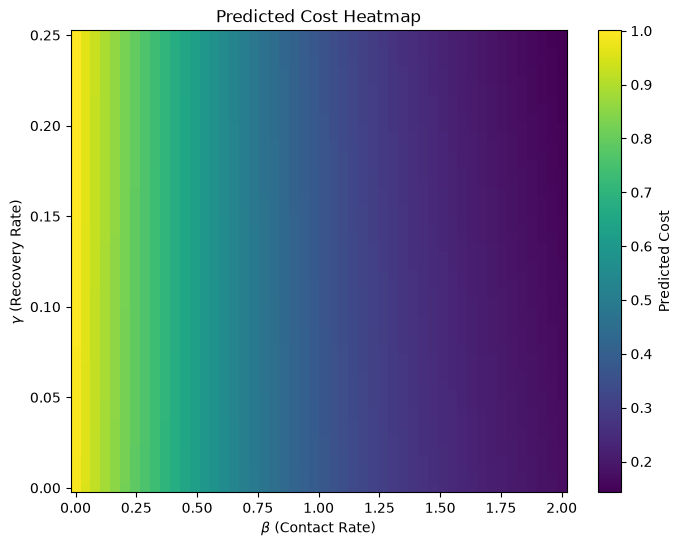

In [4]:

# Create a grid for cost visualization
b_min, b_max = 0, 2 # Approximate ranges for SIR beta
g_min, g_max = 0, 0.25   # Approximate ranges for SIR gamma
B, G = np.meshgrid(np.linspace(b_min, b_max, 50), np.linspace(g_min, g_max, 50))
grid_theta = np.stack([B.ravel(), G.ravel()], axis=1)

predicted_costs, _ = cost_model.predict(grid_theta)
COST = predicted_costs.reshape(B.shape)

plt.figure(figsize=(8, 6))
plt.pcolormesh(B, G, COST, cmap="viridis", shading="auto")
plt.colorbar(label="Predicted Cost")
plt.xlabel(r"$\beta$ (Contact Rate)")
plt.ylabel(r"$\gamma$ (Recovery Rate)")
plt.title("Predicted Cost Heatmap")
plt.show()


## 4. Initialize Cost-Aware Simulator

The `CostAwareSimulator` wraps the base simulator and uses the fitted cost model to filter samples based on a regularised cost function $g(c(\theta))$.

In [5]:
cost_aware_sim = CostAwareSimulator(simulator=sir_sim, cost_model=cost_model)


## 5. Cost-Aware Sampling

We use rejection sampling to obtain a set of cost-efficient parameters.

In [6]:
print("\nTesting cost-aware sampling...")
num_samples = 100

#Use the cost-aware sampling method
accepted_samples = cost_aware_sim.sample(batch_shape=(num_samples,1))
accepted_theta = accepted_samples.get("parameters")

#may return more than the requested number of samples. This is because of the way that rejection_sample works, in batches until it reaches the total
#number of samples
print(f"Successfully sampled {len(accepted_theta)} cost-efficient parameters.")



Testing cost-aware sampling...
Cost Aware simulator does rejection sampling based on the cost function
2666
1725
2169
Successfully sampled 137 cost-efficient parameters.


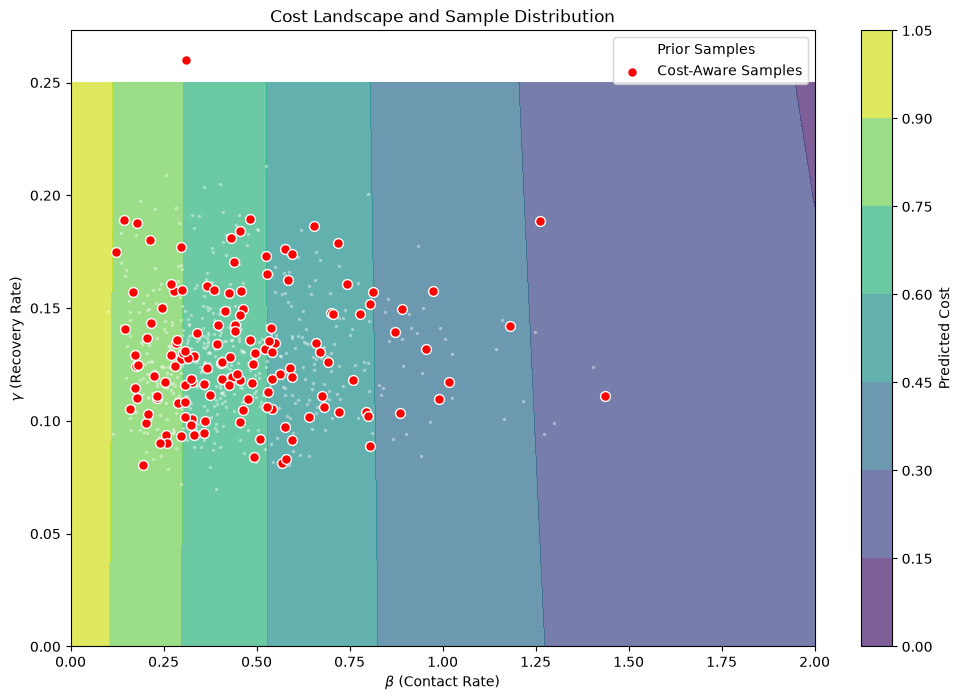

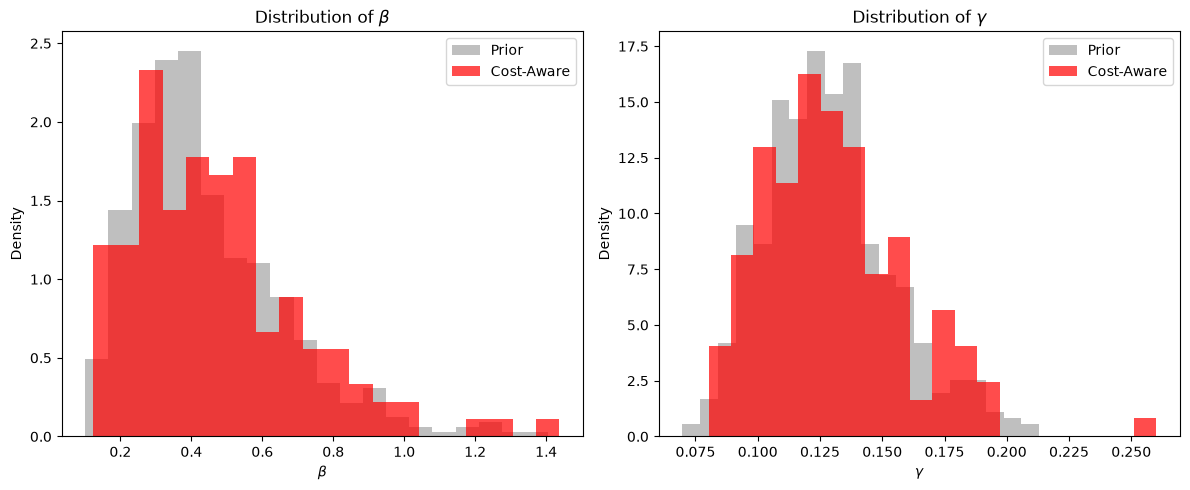

In [7]:
# Create a grid for cost visualization
b_min, b_max = 0, 2  # Approximate ranges for SIR beta
g_min, g_max = 0, 0.25  # Approximate ranges for SIR gamma
B, G = np.meshgrid(np.linspace(b_min, b_max, 50), np.linspace(g_min, g_max, 50))
grid_theta = np.stack([B.ravel(), G.ravel()], axis=1)

predicted_costs, _ = cost_model.predict(grid_theta)
COST = predicted_costs.reshape(B.shape)

plt.figure(figsize=(12, 8))
cp = plt.contourf(B, G, COST, cmap="viridis", alpha=0.7)
plt.colorbar(cp, label="Predicted Cost")

# Prior samples for comparison
prior_samples = np.array([sir_sim.prior() for _ in range(500)])
plt.scatter(
    prior_samples[:, 0],
    prior_samples[:, 1],
    color="white",
    alpha=0.3,
    s=10,
    label="Prior Samples",
    marker=".",
)

# Accepted samples
if len(accepted_theta) > 0:
    plt.scatter(
        accepted_theta[:, 0],
        accepted_theta[:, 1],
        color="red",
        edgecolors="white",
        s=50,
        label="Cost-Aware Samples",
        marker="o",
    )

plt.xlabel(r"$\beta$ (Contact Rate)")
plt.ylabel(r"$\gamma$ (Recovery Rate)")
plt.title("Cost Landscape and Sample Distribution")
plt.legend()
plt.show()

# Visualise the change in parameter distributions
plt.figure(figsize=(12, 5))

# Distribution of beta
plt.subplot(1, 2, 1)
plt.hist(prior_samples[:, 0], bins=20, alpha=0.5, label="Prior", color="gray",density=True)
if len(accepted_theta) > 0:
    plt.hist(accepted_theta[:, 0], bins=20, alpha=0.7, label="Cost-Aware", color="red",density=True)
plt.xlabel(r"$\beta$")
plt.ylabel("Density")
plt.title(r"Distribution of $\beta$")
plt.legend()

# Distribution of gamma
plt.subplot(1, 2, 2)
plt.hist(prior_samples[:, 1], bins=20, alpha=0.5, label="Prior", color="gray",density=True)
if len(accepted_theta) > 0:
    plt.hist(accepted_theta[:, 1], bins=20, alpha=0.7, label="Cost-Aware", color="red",density=True)
plt.xlabel(r"$\gamma$")
plt.ylabel("Density")
plt.title(r"Distribution of $\gamma$")
plt.legend()

plt.tight_layout()
plt.show()


## 7. Performance Metrics

We evaluate the effectiveness of the cost-aware sampling using Effective Sample Size (ESS) and Computational Gain (CG) on a test batch.

In [14]:
metrics = cost_aware_sim.compute_metrics({"theta": accepted_theta})
print("\nPerformance Metrics:")
print(f"  ESS: {metrics['ess']:.2f}")
print(f"  CG:  {metrics['cg']:.2f}")



Performance Metrics:
  ESS: 0.99
  CG:  1.01


## 8. Running the Expensive Simulator

Simulations are only generated for the accepted theta values.

In [18]:
results = np.array([sir_sim.observation_model(t) for t in accepted_theta])
print(f"\nSuccessfully simulated {len(results)} samples using the expensive simulator.")



Successfully simulated 137 samples using the expensive simulator.


## 9. Training an Approximator on Cost-Efficient Samples

Finally, we show how to use these samples to train a model, using importance weights to correct the sampling bias introduced by cost-filtering.

In [ ]:
print("\nTraining an example model on cost-efficient samples...")
num_accepted = len(accepted_theta)

if num_accepted > 0:
    train_num_candidates = 500
    
    train_observations = np.array(
        [sir_sim.observation_model(t) for t in accepted_theta]
    )

    adapter = Adapter().create_default(inference_variables=["theta"])

    #compute weights for accepted samples
    train_weights = cost_aware_sim.compute_weights(accepted_theta)

    train_data = {
        "theta": accepted_theta,
        "observations": train_observations,
        "weights": train_weights,
    }

    transformed_data = adapter(train_data)

    inference_net = nn.Sequential(
        nn.Linear(train_observations.shape[1], 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
    )

    approximator = ContinuousApproximator(
        inference_network=inference_net, adapter=adapter
    )

    data_shapes = {
        "inference_variables": accepted_theta.shape[1:],
        "inference_conditions": train_observations.shape[1:],
    }
    approximator.build(data_shapes)

    print(
        f"Model built successfully. Training on {len(accepted_theta)} samples with importance weights."
    )
    print("The workflow is now complete: Cost-aware sampling -> Model training.")
else:
    print("Skipping model training as no samples were accepted.")



Training an example model on cost-efficient samples...
Model built successfully. Training on 137 samples with importance weights.
The workflow is now complete: Cost-aware sampling -> Model training.
